# Project 2: Exploratory Data Analysis (EDA) Report
---
## Assigned Topic:
Bahrain Imports

## Selected Problem Statement:
A local business currently relies on costly third-party distributors to source products, inflating operational costs and limiting margins. The procurement team needs to analyze the last five years of import data (2021-2025) to identify historical volume trends, seasonal fluctuations, and the most cost-effective countries of origin. Finding these historical patterns will allow the business to build a direct-import strategy to bypass middlemen and reduce overall procurement costs.

## 1. Introduction & Objectives

### 1.1 Context & Background
International trade is very important for Bahrain's economy. Many local businesses buy products from third-party distributors to run their business. However, these middlemen make the products more expensive and lower the profits for local companies. By looking at historical import data, businesses can learn how to buy directly from other countries to save money.

### 1.2 Core Analytical Objectives
* Which countries are the top trading partners that send goods to Bahrain?
* How do total import values change over the years from 2021 to 2025?
* How can local businesses use these patterns to build a direct-import strategy and cut costs?

## 2. Environment Setup & Data Collection
*(Rubric Checkpoint: Ensure all modules are imported cleanly with appropriate standard aliases. Data files must be loaded using relative paths for replicability.)*

In [177]:
# Import libraries
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [178]:
# Load data using strictly relative file paths
df2021=pd.read_csv('./Data2021.csv')
df2022=pd.read_csv('./Data2022.csv')
df2023=pd.read_csv('./Data2023.csv')
df2024=pd.read_csv('./Data2024.csv')
df2025=pd.read_csv('./Data2025.csv')

In [179]:
df2024['Year']=2024

In [180]:
df2021.columns = df2021.columns.str.strip()
df2022.columns = df2022.columns.str.strip()
df2023.columns = df2023.columns.str.strip()
df2024.columns = df2024.columns.str.strip()
df2025.columns = df2025.columns.str.strip()

In [181]:
df2024.rename(columns={
    'قيمة الواردات (دينار بحريني)': 'Import Value (BD)',
    'قيمة الواردات (دولار أمريكي)': 'Import Value (USA $)',
    'وزن الواردات (كجم)': 'Import Weight (KG)',
    'كمية الواردات': 'Import Quantity',
    'وحدة القياس': 'UM'
}, inplace=True)

In [182]:
imports = pd.concat([df2021,df2022,df2023,df2024,df2025],ignore_index=True)
imports.to_csv('./df.csv')

In [183]:
#check all year are in imports
imports['Year'].value_counts()

Year
2025    324818
2024    322062
2023    321376
2022    320747
2021    314055
Name: count, dtype: int64

---
## 3. Data Handling


In [184]:
# Initial assessment: Check shapes, null values, and summary data types
imports.shape

(1603058, 15)

In [185]:
# to read ths file
imports

,N,Year,Month,Commodity No,Commodity,السلعة,UN code,Country Name,الدولة,Import Value (BD),Import Value (USA $),Import Weight (KG),Import Quantity,UM,﻿N
0,160005.0,2021,July,27101995,HYDRAULIC AND TURBO SYSTEM OILS,زيوت الأنظمة الهيدروليكية والتربونية,AE,UNITED ARAB EMIRATES,الامارات العربية المتحدة,78495.924,2.138854e+05,134176.540,134176.540,L,NaN
1,160006.0,2021,July,27101996,TRANSFORMER AND CIRCUIT BREAKER OILS,زيوت المحولات وقاطعات التيار الكهربائي,SA,SAUDI ARABIA,المملكة العربية السعودية,6997.341,1.906632e+04,12210.000,12210.000,L,NaN
2,160007.0,2021,July,27101997,"WHITE OILS (PARAFFIN OIL, VASELINE OIL)",زيوت بيضاء (مثل زيت الفازلين وزيت البارافين),KR,REPUBLIC OF KOREA,جمهورية كوريا الجنوبية,10042.109,2.736269e+04,17151.230,17151.230,L,NaN
3,160012.0,2021,July,27101998,GREASES,محضرات التشحيم,US,UNITED STATES OF AMERICA,الولايات المتّحدة الأمريكيّة,5567.980,1.517161e+04,1666.386,1666.386,KG,NaN
4,160013.0,2021,July,27101998,GREASES,محضرات التشحيم,AE,UNITED ARAB EMIRATES,الامارات العربية المتحدة,10067.373,2.743153e+04,10355.000,10355.000,KG,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1603053,NaN,2025,12 December,98010000,THE PERSONAL EFFECTS AND USED HOUSEHOLD APPLIA...,الأمتعة الشخصية والأدوات المنـزلية المستعملة ا...,TR,TURKEY,تركيا,101.000,2.686170e+02,905.000,905.000,KG,324814.0
1603054,NaN,2025,12 December,98010000,THE PERSONAL EFFECTS AND USED HOUSEHOLD APPLIA...,الأمتعة الشخصية والأدوات المنـزلية المستعملة ا...,TT,TRINIDAD&TOBAGO,ترينيداد وتوباجو,3030.000,8.058511e+03,3756.000,3756.000,KG,324815.0
1603055,NaN,2025,12 December,98010000,THE PERSONAL EFFECTS AND USED HOUSEHOLD APPLIA...,الأمتعة الشخصية والأدوات المنـزلية المستعملة ا...,US,UNITED STATES OF AMERICA,الولايات المتّحدة الأمريكيّة,2600.514,6.916261e+03,955.000,955.000,KG,324816.0
1603056,NaN,2025,12 December,98010000,THE PERSONAL EFFECTS AND USED HOUSEHOLD APPLIA...,الأمتعة الشخصية والأدوات المنـزلية المستعملة ا...,XB,Returned Bahrain Goods,بضائع بحرينية مرجعة,189.921,5.051090e+02,2110.200,2110.200,KG,324817.0


In [186]:
#heck the null values 
imports.isnull().sum()


N                        646194
Year                          0
Month                         0
Commodity No                  0
Commodity                    13
السلعة                   322075
UN code                     327
Country Name                  0
الدولة                   643438
Import Value (BD)             0
Import Value (USA $)          0
Import Weight (KG)            0
Import Quantity               0
UM                           13
﻿N                      1278240
dtype: int64

In [187]:
imports_copy=imports.copy()

In [201]:
# Data cleaning operations (handling data types, text styling, missing values, etc.)
columns_to_drop = ['الدولة', 'السلعة', 'N']
imports_copy.drop(columns=columns_to_drop, inplace=True, errors='ignore')


In [202]:
imports_copy

,Year,Month,Commodity No,Commodity,UN code,Country Name,Import Value (BD),Import Value (USA $),Import Weight (KG),Import Quantity,UM
0,2021,July,27101995,HYDRAULIC AND TURBO SYSTEM OILS,AE,UNITED ARAB EMIRATES,78495.924,2.138854e+05,134176.540,134176,L
1,2021,July,27101996,TRANSFORMER AND CIRCUIT BREAKER OILS,SA,SAUDI ARABIA,6997.341,1.906632e+04,12210.000,12210,L
2,2021,July,27101997,"WHITE OILS (PARAFFIN OIL, VASELINE OIL)",KR,REPUBLIC OF KOREA,10042.109,2.736269e+04,17151.230,17151,L
3,2021,July,27101998,GREASES,US,UNITED STATES OF AMERICA,5567.980,1.517161e+04,1666.386,1666,KG
4,2021,July,27101998,GREASES,AE,UNITED ARAB EMIRATES,10067.373,2.743153e+04,10355.000,10355,KG
...,...,...,...,...,...,...,...,...,...,...,...
1603053,2025,12 December,98010000,THE PERSONAL EFFECTS AND USED HOUSEHOLD APPLIA...,TR,TURKEY,101.000,2.686170e+02,905.000,905,KG
1603054,2025,12 December,98010000,THE PERSONAL EFFECTS AND USED HOUSEHOLD APPLIA...,TT,TRINIDAD&TOBAGO,3030.000,8.058511e+03,3756.000,3756,KG
1603055,2025,12 December,98010000,THE PERSONAL EFFECTS AND USED HOUSEHOLD APPLIA...,US,UNITED STATES OF AMERICA,2600.514,6.916261e+03,955.000,955,KG
1603056,2025,12 December,98010000,THE PERSONAL EFFECTS AND USED HOUSEHOLD APPLIA...,XB,Returned Bahrain Goods,189.921,5.051090e+02,2110.200,2110,KG


In [203]:
imports_copy.isnull().sum()

Year                    0
Month                   0
Commodity No            0
Commodity               0
UN code                 0
Country Name            0
Import Value (BD)       0
Import Value (USA $)    0
Import Weight (KG)      0
Import Quantity         0
UM                      0
dtype: int64

In [204]:
#change or delete null rows
imports_copy['Commodity'] = imports_copy['Commodity'].fillna('Unknown')
imports_copy['UN code'] = imports_copy['UN code'].fillna('Unknown')
imports_copy['UM'] = imports_copy['UM'].fillna('Unknown')
print(imports_copy[['Commodity', 'UN code', 'UM']].isnull().sum())


Commodity    0
UN code      0
UM           0
dtype: int64


In [205]:
# Check again
imports_copy.isnull().sum()

Year                    0
Month                   0
Commodity No            0
Commodity               0
UN code                 0
Country Name            0
Import Value (BD)       0
Import Value (USA $)    0
Import Weight (KG)      0
Import Quantity         0
UM                      0
dtype: int64

In [194]:
#check types
imports_copy.dtypes

Year                      int64
Month                       str
Commodity No              int64
Commodity                   str
UN code                     str
Country Name                str
Import Value (BD)       float64
Import Value (USA $)    float64
Import Weight (KG)      float64
Import Quantity         float64
UM                          str
dtype: object

In [195]:
#change the types
imports_copy['Import Quantity'] = imports_copy['Import Quantity'].astype('int64')

imports_copy.dtypes

Year                      int64
Month                       str
Commodity No              int64
Commodity                   str
UN code                     str
Country Name                str
Import Value (BD)       float64
Import Value (USA $)    float64
Import Weight (KG)      float64
Import Quantity           int64
UM                          str
dtype: object

---
## 4. Exploratory Data Analysis (EDA)
*(Rubric Checkpoint: Demonstrate mastery of basic descriptive statistics, sorting records, and applying Boolean masking techniques to isolate specific baseline metrics.)*

### 4.1. Descriptive and Summary Statistics

In [196]:
# Compute appropriate summary statistics
imports_copy.describe()

,Year,Commodity No,Import Value (BD),Import Value (USA $),Import Weight (KG),Import Quantity
count,1.603058e+06,1.603058e+06,1.603058e+06,1.603058e+06,1.603058e+06,1.603058e+06
mean,2.023014e+03,5.737208e+07,1.808642e+04,4.813182e+04,8.334538e+04,7.272540e+04
std,1.412417e+00,2.834045e+07,4.220537e+05,1.123478e+06,6.213532e+06,6.023116e+06
min,2.021000e+03,1.012110e+06,-3.132010e+02,-8.329814e+02,0.000000e+00,0.000000e+00
25%,2.022000e+03,3.307492e+07,1.222562e+02,3.254176e+02,1.098800e+01,7.000000e+00
50%,2.023000e+03,6.206900e+07,6.651035e+02,1.770088e+03,9.400000e+01,6.700000e+01
75%,2.024000e+03,8.466930e+07,3.965427e+03,1.055164e+04,1.000000e+03,7.900000e+02
max,2.025000e+03,9.898000e+07,8.977862e+07,2.387729e+08,1.668217e+09,1.668217e+09


In [197]:
#remove negative values in impo
negative_count = (imports_copy['Import Value (BD)'] < 0).sum()
print(f"Number of negative value records: {negative_count}")

imports_copy = imports_copy[imports_copy['Import Value (BD)'] >= 0]
print("-" * 50)
print(imports_copy.describe())

Number of negative value records: 1
--------------------------------------------------
               Year  Commodity No  Import Value (BD)  Import Value (USA $)  \
count  1.603057e+06  1.603057e+06       1.603057e+06          1.603057e+06   
mean   2.023014e+03  5.737209e+07       1.808643e+04          4.813186e+04   
std    1.412417e+00  2.834045e+07       4.220538e+05          1.123478e+06   
min    2.021000e+03  1.012110e+06       0.000000e+00          0.000000e+00   
25%    2.022000e+03  3.307492e+07       1.222570e+02          3.254176e+02   
50%    2.023000e+03  6.206900e+07       6.651050e+02          1.770093e+03   
75%    2.024000e+03  8.466930e+07       3.965430e+03          1.055171e+04   
max    2.025000e+03  9.898000e+07       8.977862e+07          2.387729e+08   

       Import Weight (KG)  Import Quantity  
count        1.603057e+06     1.603057e+06  
mean         8.334543e+04     7.272544e+04  
std          6.213534e+06     6.023118e+06  
min          0.000000e+00     

### 4.2. Sorting and Ranking Records

In [198]:
# Target Analysis Block 1:
highest_value_imports = imports_copy.sort_values(by='Import Value (BD)', ascending=False).head(10)
print(highest_value_imports[['Country Name', 'Commodity', 'Import Value (BD)']])

print("-" * 50)

lowest_weight_imports = imports_copy[imports_copy['Import Weight (KG)'] > 0].sort_values(by='Import Weight (KG)', ascending=True).head(5)
print(lowest_weight_imports[['Country Name', 'Commodity', 'Import Weight (KG)']])

        Country Name                                    Commodity  \
164157        BRAZIL  NON-AGGLOMERATED IRON ORES AND CONCENTRATES   
1283897    AUSTRALIA                        OTHER ALUMINIUM OXIDE   
91712         BRAZIL  NON-AGGLOMERATED IRON ORES AND CONCENTRATES   
1310967    AUSTRALIA                        OTHER ALUMINIUM OXIDE   
911306        BRAZIL  NON-AGGLOMERATED IRON ORES AND CONCENTRATES   
106349        BRAZIL  NON-AGGLOMERATED IRON ORES AND CONCENTRATES   
823511        BRAZIL  NON-AGGLOMERATED IRON ORES AND CONCENTRATES   
788134        BRAZIL  NON-AGGLOMERATED IRON ORES AND CONCENTRATES   
564801     AUSTRALIA                        OTHER ALUMINIUM OXIDE   
429089        BRAZIL  NON-AGGLOMERATED IRON ORES AND CONCENTRATES   

         Import Value (BD)  
164157        8.977862e+07  
1283897       8.608434e+07  
91712         7.732048e+07  
1310967       7.636532e+07  
911306        7.571656e+07  
106349        7.548538e+07  
823511        7.317482e+07  
788134  

### 4.3. Data Visualization

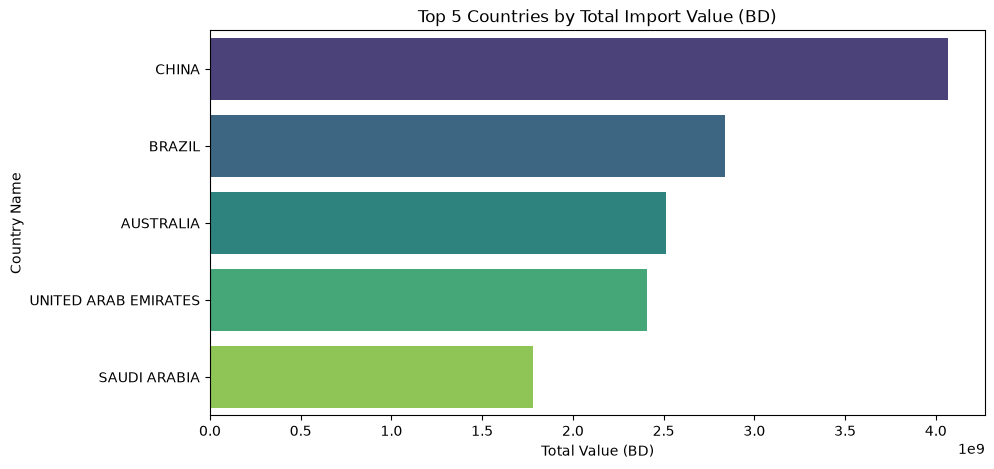

In [199]:
# Visualization 1 

top_countries = imports_copy.groupby('Country Name')['Import Value (BD)'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='viridis', legend=False)
plt.title('Top 5 Countries by Total Import Value (BD)')
plt.xlabel('Total Value (BD)')
plt.ylabel('Country Name')
plt.show()

#This bar chart shows the top 5 countries that send goods to Bahrain.
#It shows that China has the highest import value, followed by Brazil. 
#This helps us know the main trading partners of the country.

**Visualization 1 Interpretation:**
> *Write 2-3 sentences explaining exactly what relationship or pattern this chart demonstrates and how it addresses your project objectives.*

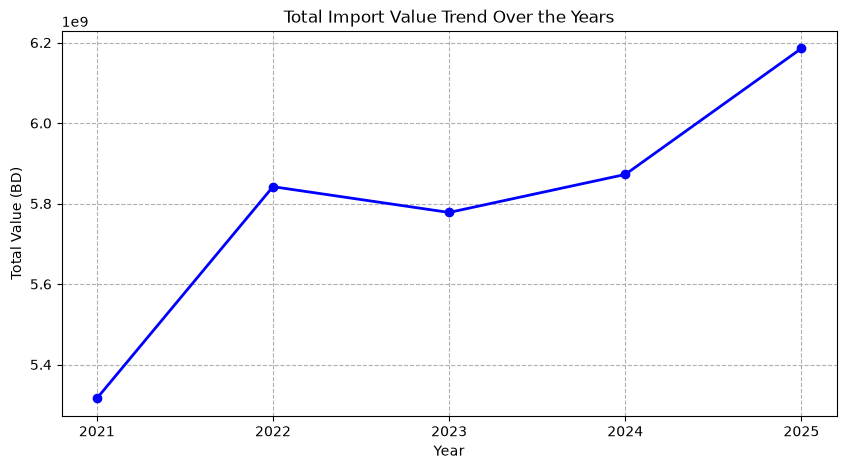

In [200]:
# Visualization 2

yearly_imports = imports_copy.groupby('Year')['Import Value (BD)'].sum()

plt.figure(figsize=(10, 5))
plt.plot(yearly_imports.index, yearly_imports.values, marker='o', color='b', linewidth=2)
plt.title('Total Import Value Trend Over the Years')
plt.xlabel('Year')
plt.ylabel('Total Value (BD)')
plt.xticks(yearly_imports.index)
plt.grid(True, linestyle='--')
plt.show()


#This line chart shows how import values changed from 2021 to 2025. 
#We can see that imports increased over time, with a small drop in 2023. 
#This helps us understand the growth pattern of trade in Bahrain.

**Visualization 2 Interpretation:**
> *Write 2-3 sentences explaining exactly what relationship or pattern this chart demonstrates and how it addresses your project objectives.*

---
## 5. Summary of Findings & Actionable Recommendations
*(Guidelines: Connect individual observations into a cohesive narrative that guides the target non-technical audience toward data-driven actions.)*

### 5.1 Key Insights (Summary of Findings)
*(Use bullet points to highlight the core truths revealed by your analysis)*
* Top Partners: China and Brazil are the biggest trading partners for Bahrain by total value.

* Growth Trend: Total imports increased from 2021 to 2025, but there was a small drop in 2023.

* Data Errors: We found one wrong row with a negative import value and cleaned it up.


### 5.2 Actionable Recommendations
*(Translate your data into clear choices or recommendations for your stakeholder based directly on the problem statement)*
* Stronger Relations: Bahrain should make better trade deals with major partners like China
* Fix System Rules: The system needs new rules to stop users from entering negative values by mistake.
* Plan for Growth: Decision-makers can use the increasing trends to plan better logistics and warehouses.

### 5.3 Limitations & Areas for Further Research
* Missing Details: The dataset does not tell us why imports dropped slightly in 2023
* More Analysis: Future studies should look into specific goods and products to see what items drive the growth most.
---

## 6. Data Dictionary & References

### 6.1 Data Dictionary
| Feature / Column | Data Type | Source | Description |
|:---|:---|:---|:---|
| Year | int64 | Original | The year the goods were imported |
| Commodity No | int64 | Original | The unique identification number for the product |
| Commodity | String | Original | The description name of the product or item |
| Country Name | String | Original | The country that sent the goods to Bahrain |
| Import Value (BD) | float64 | Original | The financial cost of the import in Bahraini Dinars |
| Import Value (USA $) | float64 | Original | The financial cost of the import in US Dollars |
| Import Weight (KG) | float64 | Original | The total weight of the goods in kilograms |
| Import Quantity | float64 | Original | The total number or count of the items |

### 6.2 References & Sources
* *Source 1:Bahrain Open Data Portal - Information & eGovernment Authority (iGA)* 